In [7]:
import pandas as pd
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dense
import matplotlib.pyplot as plt

In [8]:
data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/TSLA.csv')
data = data[['Open']]

In [9]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range = (0, 1))
scaled = scaler.fit_transform(data)

In [10]:
TEST_SIZE = 2500
train_data = scaled[:-TEST_SIZE]
test_data = scaled[-TEST_SIZE:]

In [11]:
def make_sample(data, window):
	train = []
	target = []
	for i in range(len(data)-window):
		train.append(data[i:i+window])
		target.append(data[i+window])
	return np.array(train), np.array(target)

X_train, y_train = make_sample(train_data, 30)

In [12]:
model = Sequential()
model.add(LSTM(16, input_shape=(X_train.shape[1], 1), activation='tanh', return_sequences=False))
model.add(Dense(1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [13]:
model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(X_train, y_train, epochs=100, batch_size=16)

Epoch 1/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 2.2805e-06
Epoch 2/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 5.3455e-07
Epoch 3/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4.6707e-07
Epoch 4/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4.5632e-07
Epoch 5/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 4.2723e-07
Epoch 6/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 4.4252e-07
Epoch 7/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 3.5867e-07
Epoch 8/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 3.2350e-07
Epoch 9/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2.8776e-07
Epoch 10/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.1664e-07
Epoch 11/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.2212e-07
Epoch 12/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.7481e-07
Epoch 13/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.8543e-07
Epoch 14/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.5428e-07
Epoch 15/10

78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


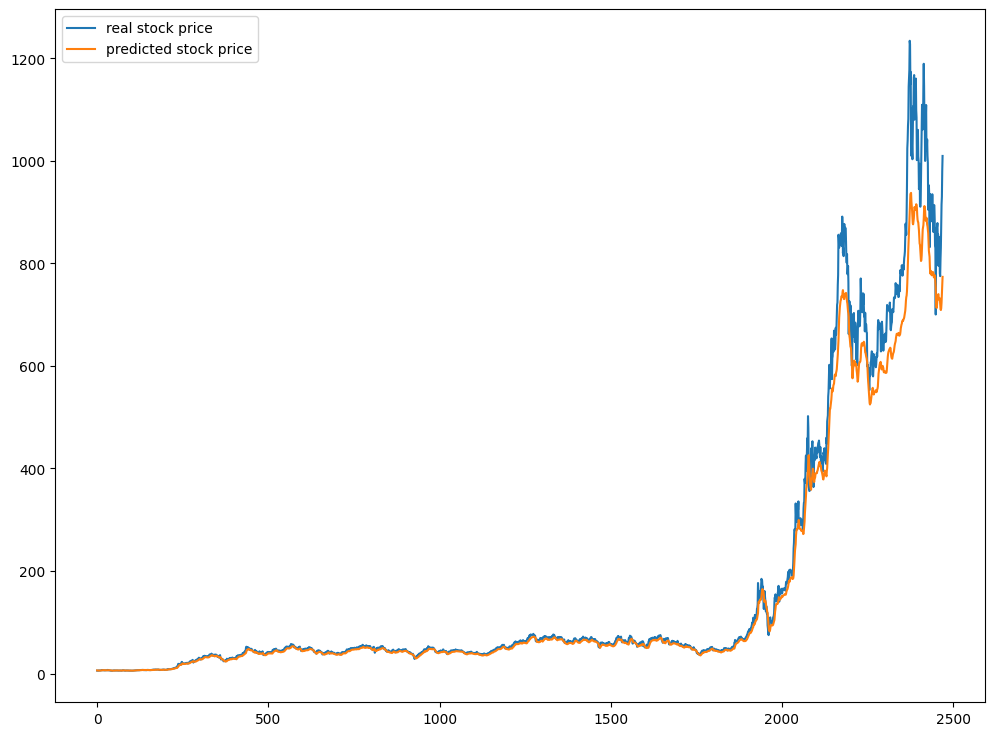

In [14]:
X_test, y_test = make_sample(test_data, 30)
y_pred = model.predict(X_test)
y_test_inv = scaler.inverse_transform(y_test)
y_pred_inv = scaler.inverse_transform(y_pred)
plt.figure(figsize=(12, 9))
plt.plot(y_test_inv, label='real stock price')
plt.plot(y_pred_inv, label='predicted stock price')
plt.legend()
plt.show()